In [ ]:
!mkdir -p ~/.kaggle
!echo '{"username":"victoriashevchuk","key":"777f787037195900bc9309e9798448cc"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:29<00:00, 241MB/s]
100% 2.04G/2.04G [00:29<00:00, 74.0MB/s]


Found 14532 images belonging to 10 classes.
Found 3628 images belonging to 10 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 973s 2s/step - accuracy: 0.6416 - loss: 1.0832 - val_accuracy: 0.8503 - val_loss: 0.4578 - learning_rate: 0.0010
Epoch 2/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 975s 2s/step - accuracy: 0.8260 - loss: 0.5176 - val_accuracy: 0.8735 - val_loss: 0.3659 - learning_rate: 0.0010
Epoch 3/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 979s 2s/step - accuracy: 0.8542 - loss: 0.4366 - val_accuracy: 0.8649 - val_loss: 0.3896 - learning_rate: 0.0010
Epoch 4/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 955s 2s/step - accuracy: 0.8747 - loss: 0.3659 - val_accuracy: 0.8837 - val_loss: 0.3263 - learning_rate: 1.0000e-04
Epoch 5/5
455/455 ━━━━━━━━━━━━━━━━━━━━ 950s 2s/step - accuracy: 0.8857 - loss: 0.3388 - val_accuracy: 0.8936 - val_loss: 0.3079 - learning_rate: 1.0000e-04
Epoch 1/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 1121s 2s/step - accuracy: 0.6461 - loss: 1.2145 - val_accuracy: 0.8895 - val_loss: 0.3253 - learning_rate: 1.0000e-05
Epoch 2/10
455/455 ━━━━━━━━━━━━━━━━━━━━ 1118s 2s/step - accuracy: 0.8505 -

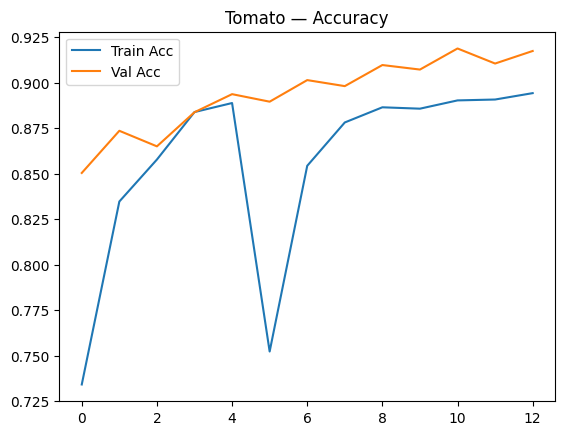

114/114 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step


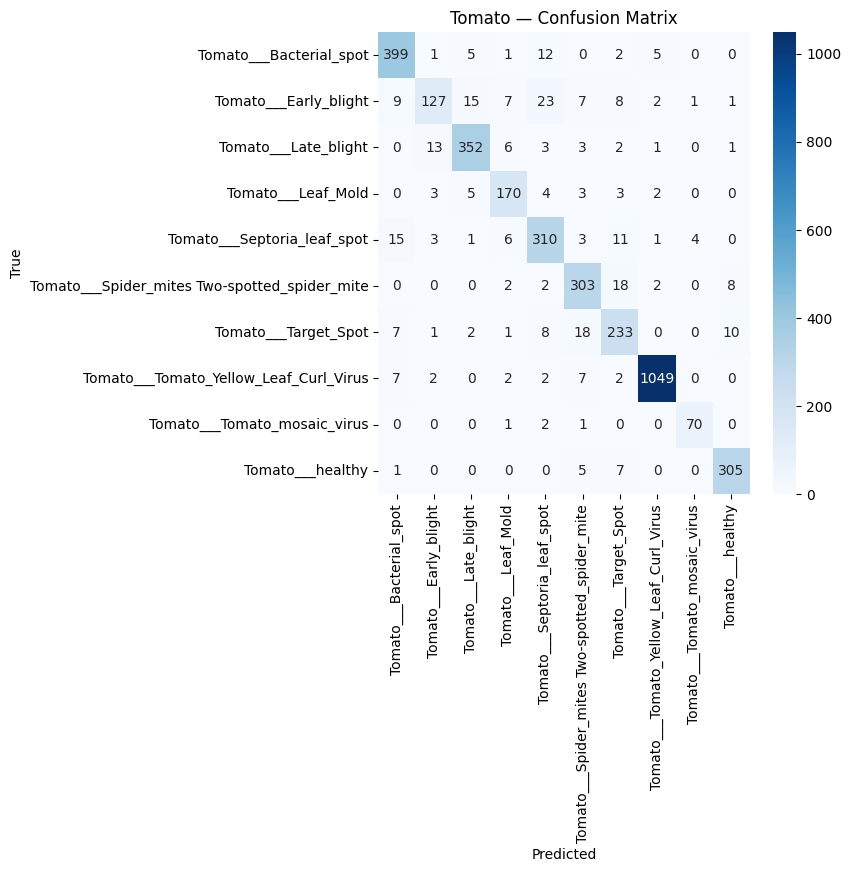

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.91      0.94      0.92       425
                        Tomato___Early_blight       0.85      0.64      0.73       200
                         Tomato___Late_blight       0.93      0.92      0.93       381
                           Tomato___Leaf_Mold       0.87      0.89      0.88       190
                  Tomato___Septoria_leaf_spot       0.85      0.88      0.86       354
Tomato___Spider_mites Two-spotted_spider_mite       0.87      0.90      0.88       335
                         Tomato___Target_Spot       0.81      0.83      0.82       280
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.98      0.98      1071
                 Tomato___Tomato_mosaic_virus       0.93      0.95      0.94        74
                             Tomato___healthy       0.94      0.96      0.95       318

                                     accu

In [ ]:
import os
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

#CHANGE PLANT NAME
TARGET_PLANT = "Tomato"
SOURCE_DIR = "/content/plantvillage dataset/color"
TEMP_DIR = f"/content/{TARGET_PLANT}_subset"

if os.path.exists(TEMP_DIR):
    shutil.rmtree(TEMP_DIR)
os.makedirs(TEMP_DIR)

for folder in os.listdir(SOURCE_DIR):
    if folder.startswith(TARGET_PLANT + "___"):
        full_path = os.path.join(SOURCE_DIR, folder)
        shutil.copytree(full_path, os.path.join(TEMP_DIR, folder))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 5
EPOCHS_FINE = 10

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

train_gen = datagen.flow_from_directory(
    TEMP_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    TEMP_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=1)
    ]
)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=1)
    ]
)

def plot_accuracy(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.title(f'{TARGET_PLANT} — Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(history, history_ft)

Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(val_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_gen.class_indices.keys(),
            yticklabels=val_gen.class_indices.keys())
plt.title(f"{TARGET_PLANT} — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(val_gen.classes, y_pred, target_names=list(val_gen.class_indices.keys())))

model.save(f'{TARGET_PLANT}_mobilenetv2.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(f'{TARGET_PLANT}_mobilenetv2.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Збережено: {TARGET_PLANT}_mobilenetv2.h5 і .tflite")


Found 2696 images belonging to 4 classes.
Found 770 images belonging to 4 classes.
Found 386 images belonging to 4 classes.
Epoch 1/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 54s 509ms/step - accuracy: 0.7412 - loss: 0.6952 - val_accuracy: 0.9377 - val_loss: 0.1655 - learning_rate: 0.0010
Epoch 2/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 34s 404ms/step - accuracy: 0.9098 - loss: 0.2007 - val_accuracy: 0.9325 - val_loss: 0.1602 - learning_rate: 0.0010
Epoch 3/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 34s 397ms/step - accuracy: 0.9356 - loss: 0.1579 - val_accuracy: 0.9416 - val_loss: 0.1424 - learning_rate: 0.0010
Epoch 4/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 34s 395ms/step - accuracy: 0.9346 - loss: 0.1595 - val_accuracy: 0.9429 - val_loss: 0.1273 - learning_rate: 0.0010
Epoch 5/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 32s 378ms/step - accuracy: 0.9380 - loss: 0.1509 - val_accuracy: 0.9364 - val_loss: 0.1529 - learning_rate: 0.0010
Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 65s 545ms/step - accuracy: 0.8841 - loss: 0.2816 - val_accuracy: 0.9442 - val_

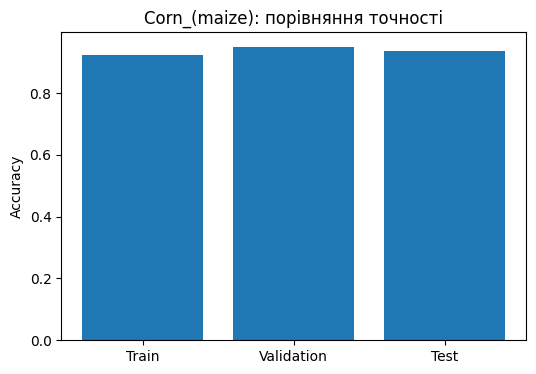

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 347ms/step


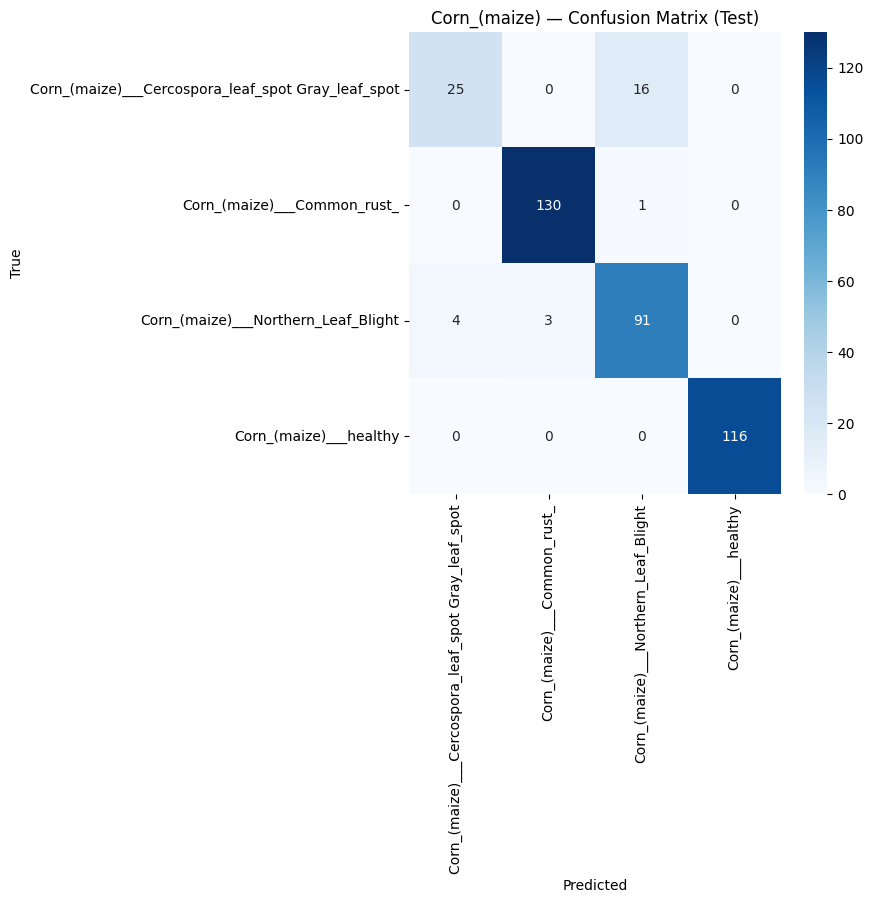

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.86      0.61      0.71        41
                       Corn_(maize)___Common_rust_       0.98      0.99      0.98       131
               Corn_(maize)___Northern_Leaf_Blight       0.84      0.93      0.88        98
                            Corn_(maize)___healthy       1.00      1.00      1.00       116

                                          accuracy                           0.94       386
                                         macro avg       0.92      0.88      0.90       386
                                      weighted avg       0.94      0.94      0.93       386

Saved artifact at '/tmp/tmp25m7c9mf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float16, name='keras_tensor_638')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.flo

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["Conv2D:", "sequential_3_1/mobilenetv2_1.00_224_1/Conv1_1/convolution@__inference_function_119533"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_120600"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.Conv2D' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["Conv2D:", "sequential_3_1/mobilenetv2_1.00_224_1/Conv1_1/convolution@__inference_function_119533"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_120600"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): see current operation: %164 = "tf.Conv2D"(%163, %11) <{data_format = "NHWC", dilations = [1, 1, 1, 1], explicit_paddings = [], padding = "SAME", strides = [

In [ ]:
import os
import shutil
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tensorflow.keras import mixed_precision, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report

TARGET_PLANT = "Corn_(maize)"
SRC_DIR = "/content/plantvillage dataset/color"
BASE_DIR = f"/content/{TARGET_PLANT}_split"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 5
EPOCHS_FINE   = 10
SEED = 42

mixed_precision.set_global_policy('mixed_float16')

for subset in ("train","val","test"):
    dirpath = os.path.join(BASE_DIR, subset)
    if os.path.exists(dirpath):
        shutil.rmtree(dirpath)
    os.makedirs(dirpath)

all_images = []
for folder in os.listdir(SRC_DIR):
    if folder.startswith(TARGET_PLANT + "___"):
        full = os.path.join(SRC_DIR, folder)
        for fname in os.listdir(full):
            all_images.append((full, fname, folder))

random.seed(SEED)
random.shuffle(all_images)
n = len(all_images)
n_train = int(0.7 * n)
n_val   = int(0.2 * n)

splits = {
    "train": all_images[:n_train],
    "val":   all_images[n_train:n_train+n_val],
    "test":  all_images[n_train+n_val:]
}

for subset, items in splits.items():
    for src_folder, fname, cls in items:
        dst_folder = os.path.join(BASE_DIR, subset, cls)
        os.makedirs(dst_folder, exist_ok=True)
        shutil.copy(os.path.join(src_folder, fname),
                    os.path.join(dst_folder, fname))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, zoom_range=0.2, shear_range=0.2,
    horizontal_flip=True, width_shift_range=0.2,
    height_shift_range=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
val_gen = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "val"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

#freeze
base = MobileNetV2(input_shape=IMG_SIZE+(3,), include_top=False, weights='imagenet')
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=1)
    ]
)

# Fine-tuning останніх 30 шарів
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=1)
    ]
)

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test accuracy: {test_acc:.4f}")

train_acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc   = history.history['val_accuracy'] + history_ft.history['val_accuracy']
final_acc = [train_acc[-1], val_acc[-1], test_acc]

plt.figure(figsize=(6,4))
plt.bar(["Train","Validation","Test"], final_acc)
plt.ylabel("Accuracy")
plt.title(f"{TARGET_PLANT}: порівняння точності")
plt.show()

Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys(),
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{TARGET_PLANT} — Confusion Matrix (Test)")
plt.show()

print(classification_report(
    test_gen.classes, y_pred,
    target_names=list(test_gen.class_indices.keys())
))

model.save(f'{TARGET_PLANT}_mobilenetv2.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(f'{TARGET_PLANT}_mobilenetv2.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Збережено: {TARGET_PLANT}_mobilenetv2.h5 і .tflite")


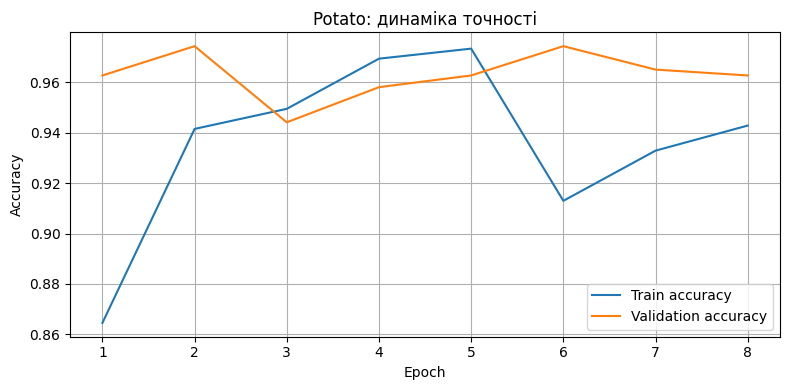

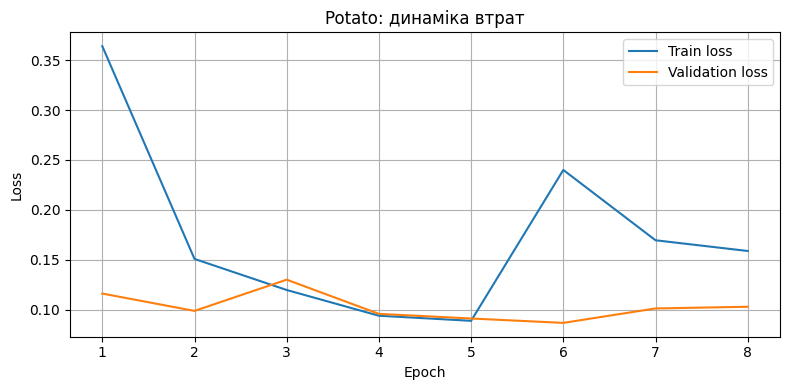

In [ ]:
#Шукала ідеал графіка
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc, label='Train accuracy')
plt.plot(epochs, val_acc,   label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'{TARGET_PLANT}: динаміка точності')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

train_loss = history.history['loss'] + history_ft.history['loss']
val_loss   = history.history['val_loss'] + history_ft.history['val_loss']

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, label='Train loss')
plt.plot(epochs, val_loss,   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{TARGET_PLANT}: динаміка втрат')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


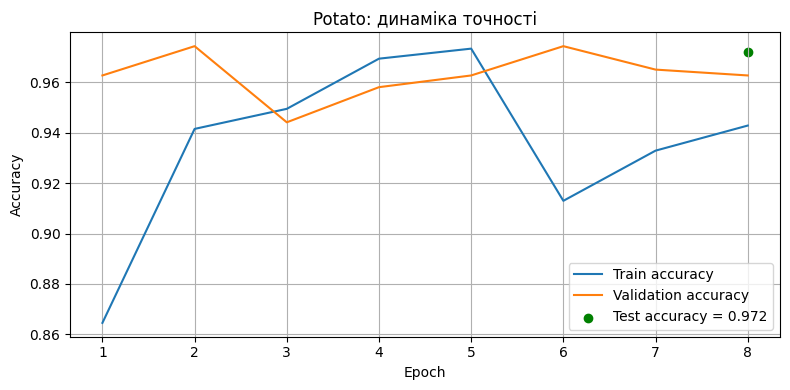

In [ ]:
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc, label='Train accuracy')
plt.plot(epochs, val_acc,   label='Validation accuracy')

# додаємо одиничну крапку тесту на останній епосі
plt.scatter(len(epochs), test_acc, c='green', marker='o',
            label=f'Test accuracy = {test_acc:.3f}')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'{TARGET_PLANT}: динаміка точності')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc   = history.history['val_accuracy'] + history_ft.history['val_accuracy']

plt.plot(train_acc, label='Train Acc')       # синя лінія за замовчуванням
plt.plot(val_acc,   label='Val Acc')         # помаранчева лінія за замовчуванням
plt.title(f'{TARGET_PLANT} — Accuracy')
plt.legend()
plt.ylim(0.7, 1.0)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


Found 2843 images belonging to 4 classes.
Found 812 images belonging to 4 classes.
Found 407 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 62s 570ms/step - accuracy: 0.7399 - loss: 0.6516 - val_accuracy: 0.9606 - val_loss: 0.1117 - learning_rate: 0.0010
Epoch 2/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 66s 442ms/step - accuracy: 0.9575 - loss: 0.1232 - val_accuracy: 0.9692 - val_loss: 0.0822 - learning_rate: 0.0010
Epoch 3/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 467ms/step - accuracy: 0.9640 - loss: 0.1020 - val_accuracy: 0.9741 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 4/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 39s 433ms/step - accuracy: 0.9734 - loss: 0.0748 - val_accuracy: 0.9717 - val_loss: 0.0784 - learning_rate: 0.0010
Epoch 5/5
89/89 ━━━━━━━━━━━━━━━━━━━━ 41s 434ms/step - accuracy: 0.9676 - loss: 0.0919 - val_accuracy: 0.9729 - val_loss: 0.0708 - learning_rate: 1.0000e-04
Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 73s 582ms/step - accuracy: 0.8714 - loss: 0.3491 - val_accuracy: 0.9778 - val_loss: 0.0520 - learning_rate: 1.0000e-05
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 39s 442ms/step - accuracy: 0.9345 - loss:

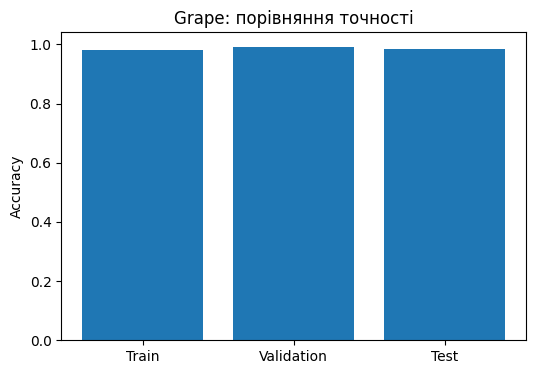

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 336ms/step


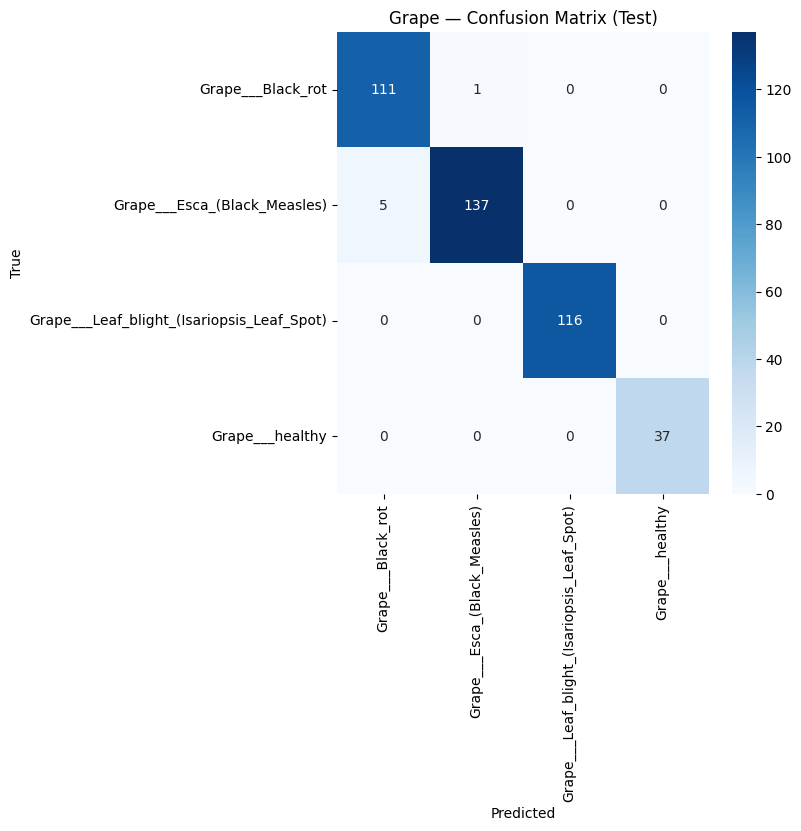

                                            precision    recall  f1-score   support

                         Grape___Black_rot       0.96      0.99      0.97       112
              Grape___Esca_(Black_Measles)       0.99      0.96      0.98       142
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       1.00      1.00      1.00       116
                           Grape___healthy       1.00      1.00      1.00        37

                                  accuracy                           0.99       407
                                 macro avg       0.99      0.99      0.99       407
                              weighted avg       0.99      0.99      0.99       407

Saved artifact at '/tmp/tmpehqlmqg7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float16, name='keras_tensor_960')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float16, name=None)
Captures:
  136935793521872: TensorSpec(shape=(

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["Conv2D:", "sequential_5_1/mobilenetv2_1.00_224_1/Conv1_1/convolution@__inference_function_194650"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_195717"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.Conv2D' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["Conv2D:", "sequential_5_1/mobilenetv2_1.00_224_1/Conv1_1/convolution@__inference_function_194650"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_195717"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): see current operation: %164 = "tf.Conv2D"(%163, %11) <{data_format = "NHWC", dilations = [1, 1, 1, 1], explicit_paddings = [], padding = "SAME", strides = [

In [ ]:
import os
import shutil
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tensorflow.keras import mixed_precision, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report

TARGET_PLANT = "Grape"
SRC_DIR = "/content/plantvillage dataset/color"
BASE_DIR = f"/content/{TARGET_PLANT}_split"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 5
EPOCHS_FINE   = 10
SEED = 42

mixed_precision.set_global_policy('mixed_float16')

for subset in ("train","val","test"):
    dirpath = os.path.join(BASE_DIR, subset)
    if os.path.exists(dirpath):
        shutil.rmtree(dirpath)
    os.makedirs(dirpath)

all_images = []
for folder in os.listdir(SRC_DIR):
    if folder.startswith(TARGET_PLANT + "___"):
        full = os.path.join(SRC_DIR, folder)
        for fname in os.listdir(full):
            all_images.append((full, fname, folder))

random.seed(SEED)
random.shuffle(all_images)
n = len(all_images)
n_train = int(0.7 * n)
n_val   = int(0.2 * n)

splits = {
    "train": all_images[:n_train],
    "val":   all_images[n_train:n_train+n_val],
    "test":  all_images[n_train+n_val:]
}

for subset, items in splits.items():
    for src_folder, fname, cls in items:
        dst_folder = os.path.join(BASE_DIR, subset, cls)
        os.makedirs(dst_folder, exist_ok=True)
        shutil.copy(os.path.join(src_folder, fname),
                    os.path.join(dst_folder, fname))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, zoom_range=0.2, shear_range=0.2,
    horizontal_flip=True, width_shift_range=0.2,
    height_shift_range=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
val_gen = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "val"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

base = MobileNetV2(input_shape=IMG_SIZE+(3,), include_top=False, weights='imagenet')
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=1)
    ]
)

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=1)
    ]
)

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test accuracy: {test_acc:.4f}")

train_acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc   = history.history['val_accuracy'] + history_ft.history['val_accuracy']
final_acc = [train_acc[-1], val_acc[-1], test_acc]

plt.figure(figsize=(6,4))
plt.bar(["Train","Validation","Test"], final_acc)
plt.ylabel("Accuracy")
plt.title(f"{TARGET_PLANT}: порівняння точності")
plt.show()

Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys(),
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{TARGET_PLANT} — Confusion Matrix (Test)")
plt.show()

print(classification_report(
    test_gen.classes, y_pred,
    target_names=list(test_gen.class_indices.keys())
))

model.save(f'{TARGET_PLANT}_mobilenetv2.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(f'{TARGET_PLANT}_mobilenetv2.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Збережено: {TARGET_PLANT}_mobilenetv2.h5 і .tflite")


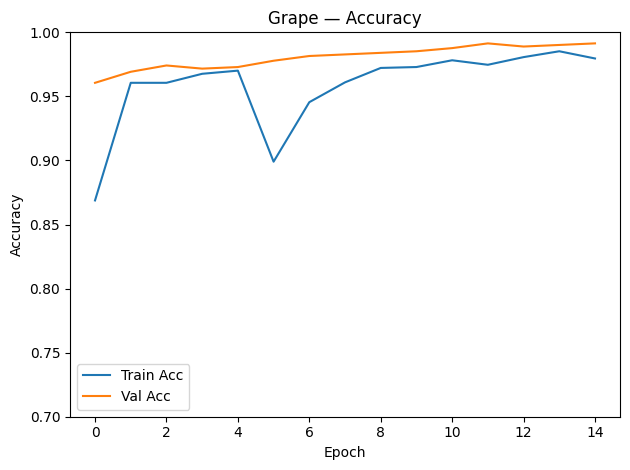

In [ ]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc   = history.history['val_accuracy'] + history_ft.history['val_accuracy']

plt.plot(train_acc, label='Train Acc')       # синя лінія за замовчуванням
plt.plot(val_acc,   label='Val Acc')         # помаранчева лінія за замовчуванням
plt.title(f'{TARGET_PLANT} — Accuracy')
plt.legend()
plt.ylim(0.7, 1.0)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


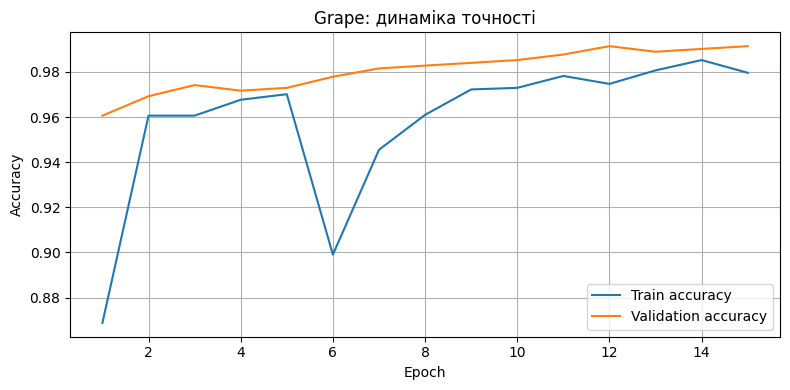

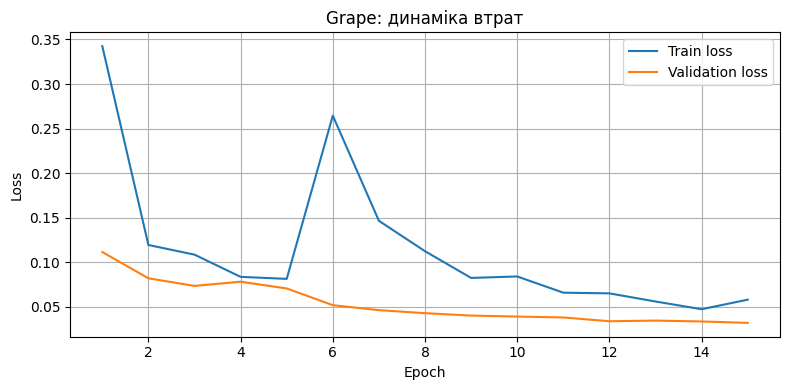

In [ ]:
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc, label='Train accuracy')
plt.plot(epochs, val_acc,   label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'{TARGET_PLANT}: динаміка точності')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

train_loss = history.history['loss'] + history_ft.history['loss']
val_loss   = history.history['val_loss'] + history_ft.history['val_loss']

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, label='Train loss')
plt.plot(epochs, val_loss,   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{TARGET_PLANT}: динаміка втрат')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

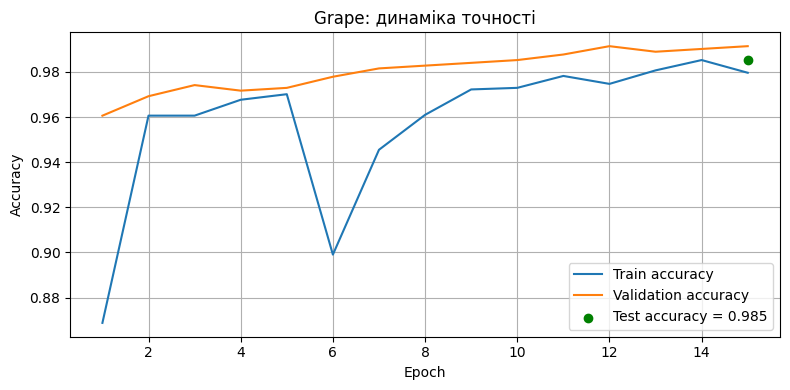

In [ ]:
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc, label='Train accuracy')
plt.plot(epochs, val_acc,   label='Validation accuracy')

plt.scatter(len(epochs), test_acc, c='green', marker='o',
            label=f'Test accuracy = {test_acc:.3f}')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'{TARGET_PLANT}: динаміка точності')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()